# 전체 학습 과정 및 아키텍쳐

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Phase 1~2는 인덱싱 단계입니다. 데이터를 청킹해서 LLM이 그래프로 만들고 Neo4j에 저장합니다. 이어서 검색·생성 단계입니다.

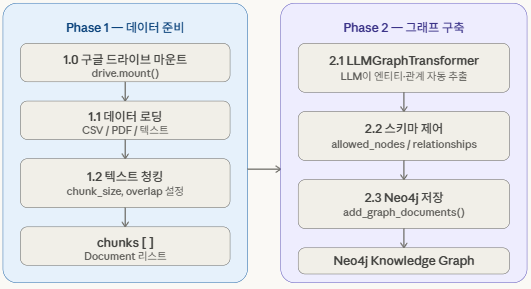

Phase 3~4는 검색·생성 단계입니다. 질문이 들어오면 그래프 탐색과 벡터 검색을 동시에 하고 합쳐서 LLM에게 넘깁니다. 마지막으로 Phase 5입니다.  
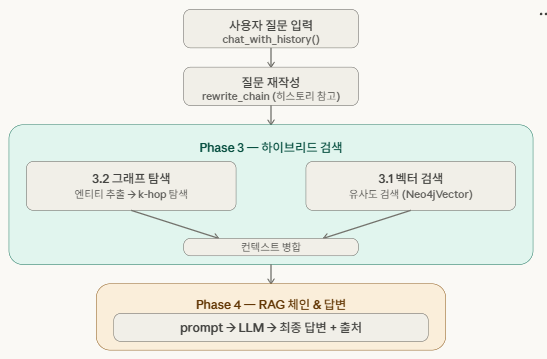

Phase 5는 Phase 3~4의 하이브리드 검색과 달리 질문 유형에 따라 한 경로만 실행합니다. 관계형 질문이면 그래프만, 의미 검색이면 벡터만 타서 불필요한 API 호출을 줄입니다.  
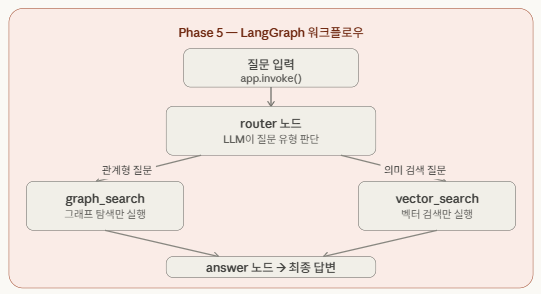

# Phase 0 — 개념 이해 & 환경 준비

## 0.1 GraphRAG vs 일반 RAG — 언제 써야 하나?
- **일반 RAG**는 문서를 청크로 쪼개고 벡터 유사도로 검색합니다. "이 문장과 비슷한 청크를 찾아줘" 방식이라, 단순 사실 조회에는 충분합니다.

- **GraphRAG**는 여기에 더해 엔티티(노드)와 관계(엣지)로 이뤄진 지식 그래프를 활용합니다. "A는 B와 어떤 관계인가?", "C를 통해 연결된 모든 D를 찾아줘" 같은 다중 홉 추론이 필요할 때 강점을 발휘합니다.

- **GraphRAG를 선택해야 할 때**:
· 엔티티 간 관계가 중요한 데이터 (논문, 계약서, 조직도, 제품 카탈로그)
· 여러 문서를 가로질러 추론해야 하는 질문
· "누가 누구와 일했나", "어떤 제품이 어떤 카테고리에 속하나" 같은 관계형 질문

## 0.2 최신 GraphRAG 전체

- Indexing (그래프 구축)  
문서 로드 → 청킹 → LLMGraphTransformer로 엔티티·관계 추출 → Neo4j 저장 + 벡터 임베딩 생성

- Retrieval (검색)  
질문 입력 → 엔티티 추출 → ① 그래프 탐색(k-hop) + ② 벡터 유사도 검색 → 두 결과 병합

- Generation (생성)  
병합된 컨텍스트 → LLM → 최종 답변

## 0.3 패키지 설치

In [5]:
%pip install --upgrade --quiet \
    langchain \
    langchain-core \
    langchain-community \
    langchain-openai \
    langchain-experimental \
    langchain-neo4j \
    neo4j \
    python-dotenv \
    tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.7/112.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.7/506.7 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.1/210.1 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.3/325.3 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.0/234.0 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7

## 0.4 환경변수 설정 & Neo4j AuraDB 연결 테스트

### 연결 테스트 코드

In [ ]:
import os
from dotenv import load_dotenv
from langchain_neo4j import Neo4jGraph

load_dotenv()

graph = Neo4jGraph(
    url=NEO4J_URI,
    username=NEO4J_USERNAME,
    password=NEO4J_PASSWORD,
    database=NEO4J_DATABASE
)

# 연결 확인
result = graph.query("RETURN 1 AS ping")
print(result)  # [{'ping': 1}] 이면 성공

[{'ping': 1}]


# Phase 1 — 데이터 준비 & 문서 청킹

## 1.1 데이터 로딩 — CSV / PDF / 텍스트

### CSV

In [ ]:
import pandas as pd
from langchain_core.documents import Document
import os

df = pd.read_csv("/content/drive/MyDrive/아이펠톤/data/final_data.csv", encoding='cp949', sep=None, engine='python')

In [ ]:
df.head()

,title,link,pub_date,content
0,로봇은 왜 인간의 모습을 하고 있는가?,http://www.brainmedia.co.kr/Opinion/25313,"Tue, 31 Mar 2026 08:44:00 +0900",분야별 TV 매거진 한양대 공학대학 로봇공학과 한재권 교수 한재권 교수는 한양대학교...
1,[결정의 순간들①] 정주영·정세영의 유산 'HDC 정몽규',https://www.meconomynews.com/news/articleView....,"Tue, 31 Mar 2026 09:38:00 +0900",정몽규 회장은 대한민국 재벌이다. 고 정주영 회장의 조카로 태어나 현대자동차 회장으...
2,[이슈체크] 이란전쟁 한달 만에 시총 840조 증발…'삼전닉스'만 372조원...,https://www.tfmedia.co.kr/news/article.html?no...,"Tue, 31 Mar 2026 08:50:00 +0900",2026.03.31 이란전쟁 여파로 3월 한 달간 국내 증시 상장사 전체 시가총액이...
3,"[TECH한주] 'K-라이다'의 자존심 에스오에스랩, 피지컬 AI의 '눈'을 넘어...",https://www.epnc.co.kr/news/articleView.html?i...,"Tue, 31 Mar 2026 08:00:00 +0900",에스오에스랩은 2016년 광주과학기술원 박사급 인력들이 의기투합해 설립한 국내 최고...
4,YTN '저널리즘 책무위' 가동… 노조 &quot;유진 강점기 합리화 명분&quot;,https://n.news.naver.com/mnews/article/127/000...,"Mon, 30 Mar 2026 15:25:00 +0900","30일 이사회 김백 대국민사과, 현대자동차 기사 삭제 조사YTN지부 양상우 사단 경..."


In [ ]:
import pandas as pd
from langchain_core.documents import Document
import os
save_path = '/content/drive/MyDrive/아이펠톤/data'
file_name = "/content/drive/MyDrive/아이펠톤/data/final_data.csv"
full_path = os.path.join(save_path, file_name)

# CSV → LangChain Document 변환
df = pd.read_csv(full_path, encoding='cp949', sep=None, engine='python')

TARGET_COLS = ["title", "content"]
METADATA_COLS  = ["pub_date", "link"]

docs = []
for _, row in df.iterrows():
    content = "\n".join(
        f"{col}: {row[col]}"
        for col in TARGET_COLS
        if pd.notna(row[col])
    )

    meta = {"source": file_name, "row": _}
    for col in METADATA_COLS:
        if pd.notna(row[col]):
            meta[col] = row[col]

    docs.append(Document(page_content=content, metadata=meta))


print(f"로드된 문서 수: {len(docs)}")
print(docs[0].page_content[:200])  # 첫 번째 문서 미리보기

로드된 문서 수: 1134
title: 로봇은 왜 인간의 모습을 하고 있는가?
content: 분야별 TV 매거진 한양대 공학대학 로봇공학과 한재권 교수 한재권 교수는 한양대학교 로봇공학과 부교수이자, 휴머노이드 전문 스타트업 AeiROBOT 의 최고기술책임자로 활동하며, 실제 산업 현장 적용이 가능한 로봇 개발을 선도하고 있습니다. 세계적 로봇대회 RoboCup Humanoid L


### 협력사 정보 데이터

In [ ]:
from neo4j import GraphDatabase

def check_node_exists(tx, node_name):
    # EXISTS() 함수를 사용하여 성능 최적화 (불필요한 전체 속성 로드 방지)
    query = """
    MATCH (c:Company {id: $id})
    RETURN count(c) > 0 AS is_present
    """
    result = tx.run(query, id=node_name)
    return result.single()["is_present"]

# --- 실행부 ---
URI = ''
AUTH = ("", "")
TARGET_NAME = "현대자동차"

driver = GraphDatabase.driver(URI, auth=AUTH)

with driver.session() as session:
    exists = session.execute_read(check_node_exists, TARGET_NAME)

    if exists:
        print(f"✅ '{TARGET_NAME}' 노드가 존재합니다.")
    else:
        print(f"❌ '{TARGET_NAME}' 노드를 찾을 수 없습니다.")

driver.close()

✅ '현대자동차' 노드가 존재합니다.


In [ ]:
import pandas as pd
from neo4j import GraphDatabase

# --- 접속 정보 ---

FILE_PATH = "/content/drive/MyDrive/아이펠톤/data/hmg_partners_900 (1).csv"

class RiskGraphUploader:
    def __init__(self, uri, auth):
        self.driver = GraphDatabase.driver(uri, auth=auth)

    def close(self):
        self.driver.close()

    def upload_data(self, file_path):
        # CSV 로드 (회사명, 업종 컬럼 사용)
        df = pd.read_csv(file_path)

        with self.driver.session() as session:
            print("🏗️ 리스크 온톨로지(SUPPLIES_TO / BELONGS_TO) 적재 시작...")
            for _, row in df.iterrows():
                session.execute_write(self._create_risk_relationships, row)
            print(f"✅ 총 {len(df)}개의 공급망 지식 그래프 구성 완료!")

    @staticmethod
    def _create_risk_relationships(tx, row):
        """
        설계 규칙:
        1. (협력사:Supplier {id: 회사명}) -[:SUPPLIES_TO]-> (현대차:Company {id: '현대자동차'})
        2. (협력사:Supplier {id: 회사명}) -[:BELONGS_TO]-> (부품:SupplyItem {name: 업종})
        """
        query = """
        // 1. 최상위 타겟 기업(현대자동차) 확보
        MERGE (main:Company {id: '현대자동차'})

        // 2. 협력사 노드 생성 (라벨: Supplier)
        MERGE (sub:Supplier {id: $company_name})

        // 3. 부품/업종 노드 생성 (라벨: SupplyItem)
        MERGE (item:SupplyItem {name: $industry})

        // 4. 관계 설정
        // 협력사가 현대차에 직접 납품함
        MERGE (sub)-[:SUPPLIES_TO]->(main)

        // 협력사가 특정 부품/품목 카테고리에 속함
        MERGE (sub)-[:BELONGS_TO]->(item)
        """
        tx.run(query,
               company_name=row['회사명'],
               industry=row['업종'])

# --- 실행 ---
if __name__ == "__main__":
    uploader = RiskGraphUploader(URI, AUTH)
    try:
        uploader.upload_data(FILE_PATH)
    except Exception as e:
        print(f"❌ 오류 발생: {e}")
    finally:
        uploader.close()

🏗️ 리스크 온톨로지(SUPPLIES_TO / BELONGS_TO) 적재 시작...
✅ 총 901개의 공급망 지식 그래프 구성 완료!


In [ ]:
import pandas as pd
from neo4j import GraphDatabase

# --- 설정 정보 ---
FILE_PATH = "/content/drive/MyDrive/아이펠톤/data/hmg_partners_900 (1).csv"  # 파일명에 맞게 수정하세요

class RiskOntologyUploader:
    def __init__(self, uri, auth):
        self.driver = GraphDatabase.driver(uri, auth=auth)

    def close(self):
        self.driver.close()

    def upload_data(self, file_path):
        # 데이터 로드
        df = pd.read_csv(file_path)

        with self.driver.session() as session:
            print("🏗️ Supplier 기반 리스크 온톨로지 적재 시작...")
            for _, row in df.iterrows():
                session.execute_write(self._create_supplier_hierarchy, row)
            print(f"✅ 총 {len(df)}개의 노드 및 관계 구성 완료!")

    @staticmethod
    def _create_supplier_hierarchy(tx, row):
        """
        1. Company (현대자동차) 탐색
        2. Supplier (공급망 카테고리) 생성 (예: 자동차 부품, 반도체/전자)
        3. Company (협력사) 생성 및 속성 설정
        4. 관계: (협력사)-[:PARTNERS_WITH]->(현대차), (협력사)-[:BELONGS_TO]->(공급망)
        """
        query = """
        // 1. 타겟 기업 확보
        MATCH (target:Company {id: '현대자동차'})

        // 2. 공급망 그룹(Supplier) 생성 - 업종명을 이름으로 사용
        MERGE (sup:Supplier {id: $company_name})

        // 3. 개별 협력사(Company) 생성
        MERGE (partner:Company {id: $company_name})
        SET partner.business_summary = $summary,
            partner.role = 'Partner'

        // 4. 관계 설정 (Ontology 준수)
        MERGE (partner)-[:PARTNERS_WITH]->(target)
        MERGE (partner)-[:BELONGS_TO]->(sup)
        """
        tx.run(query,
               company_name=row['회사명'],
               supplier_category=row['업종'],
               summary=row['비즈니스 요약'])

# --- 실행 ---
if __name__ == "__main__":
    uploader = RiskOntologyUploader(URI, AUTH)
    try:
        uploader.upload_data(FILE_PATH)
    except Exception as e:
        print(f"❌ 오류 발생: {e}")
    finally:
        uploader.close()
        uploader.close()

In [ ]:
df_rel = pd.read_csv("/content/drive/MyDrive/아이펠톤/data/hmg_partners_900 (1).csv")
df_rel


,회사명,업종,비즈니스 요약
0,현대트랜시스,자동차 부품,"변속기, 액슬, 시트 등 자동차 핵심 파워트레인 및 내장 부품 제조"
1,현대위아,자동차 부품 및 기계,"엔진, 구동부품 등 자동차 부품과 공작기계 및 방산 부품 생산"
2,현대케피코,자동차 부품,"엔진 및 변속기 제어기, 센서류 등 차량용 전자제어시스템 제조"
3,현대모비스,자동차 부품,"모듈 제조, AS부품 공급 및 자율주행, 전동화 핵심 부품 생산"
4,현대엠시트,자동차 부품,자동차용 시트 프레임 및 시트 완제품 전문 제조
...,...,...,...
896,로보케어,로봇,사회 약자를 위한 돌봄 로봇 및 교육용 로봇 생산
897,티라유텍,IT/소프트웨어,스마트 팩토리 운영 시스템(MES) 및 물류 자동화 솔루션
898,비츠로셀,배터리/전기,리튬 일차전지 및 자동차 전장용 전원 솔루션
899,아나패스,반도체/전자,디스플레이용 타이밍 컨트롤러 및 시스템 반도체 설계


### PDF

In [ ]:
# from langchain_community.document_loaders import PyPDFLoader

# loader = PyPDFLoader("your_document.pdf")
# docs = loader.load()

# print(f"로드된 페이지 수: {len(docs)}")
# print(docs[0].page_content[:200])  # 첫 페이지 미리보기

### 텍스트

In [ ]:
# from langchain_community.document_loaders import TextLoader

# loader = TextLoader("your_document.txt", encoding="utf-8")
# docs = loader.load()

# print(f"로드된 문서 수: {len(docs)}")
# print(docs[0].page_content[:200])

## 1.2 텍스트 청킹 & 품질 확인

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=600,
    chunk_overlap=60,
    separators=["\n\n", "\n", ".", " ", ""],
)

chunks = splitter.split_documents(docs)

print(f"원본 문서 수  : {len(docs)}")
print(f"청킹 후 조각  : {len(chunks)}")
print(f"평균 청크 길이 : {sum(len(c.page_content) for c in chunks) // len(chunks)} 자")
print()
print("─" * 40)
print("[청크 0]")
print(chunks[0].page_content)
print()
print("[청크 1 앞부분 — overlap 확인]")
print(chunks[1].page_content[:120], "...")

원본 문서 수  : 1134
청킹 후 조각  : 1789
평균 청크 길이 : 275 자

────────────────────────────────────────
[청크 0]
title: 로봇은 왜 인간의 모습을 하고 있는가?

[청크 1 앞부분 — overlap 확인]
content: 분야별 TV 매거진 한양대 공학대학 로봇공학과 한재권 교수 한재권 교수는 한양대학교 로봇공학과 부교수이자, 휴머노이드 전문 스타트업 AeiROBOT 의 최고기술책임자로 활동하며, 실제 산업 현장 적용 ...


In [ ]:
len(chunks)

1789

# Phase 2 — Knowledge Graph 자동 구축

## 2.1 LLMGraphTransformer 초기화

In [ ]:
from langchain_experimental.graph_transformers import LLMGraphTransformer
from langchain_openai import ChatOpenAI
import os

llm = ChatOpenAI(
    model="gpt-4o-mini",      # 추출용으로 가성비가 좋은 모델
    temperature=0,
    openai_api_key=OPENAI_API_KEY
)

# 1. 노드 타입 정의 (리스크 탐지 및 대응 구조 중심)
allowed_nodes = [
    "Company",       # 현대자동차, 기아 등 (Target)
    "Competitor",    # 테슬라, BYD, 구글 등 (경쟁사)
    "Supplier",      # 부품사 및 원자재 공급처
    "Event",         # 뉴스 속 구체적 사건 (이란전쟁, 터보퀀트 출시 등)
    "RiskCategory",  # 7대 리스크 (지정학, 경쟁, 운영, 재무, 규제 등)
    "Strategy",     # 현대차의 리스크 대응 전략 및 실행 계획  ← 추가
    "MarketIndicator", # 지수 및 매크로 지표 (코스피, 환율, 금리 등)
    "StockMarket",   # 코스피, 나스닥, 미국 등
    "SupplyItem",   # 배터리, 반도체, 리튬 등 조달 품목
    "Country",      # 미국, 중국 등 이슈 발생국·판매국·생산국
]

# 2. 관계 정의 (인과관계 및 대응 중심)
allowed_relationships = [
    "CAUSES",        # Event -> RiskCategory (사건이 리스크 유발)
    "AFFECTS",       # RiskCategory -> Company (리스크가 기업에 영향)
    "LEADS_TO",      # RiskCategory -> Impact (리스크가 구체적 피해로 이어짐)
    "COMPETES_WITH", # Company <-> Competitor (경쟁 관계)
    "SUPPLIES_TO",   # Supplier -> Company (공급 관계)
    "ADOPTS",        # Company -> Response (기업이 대응책 채택)
    "ADDRESSES",     # Response -> RiskCategory (대응책이 리스크 완화),
    "PARTNERS_WITH",  # 협력/제휴
    "OCCURRED_IN",    # RiskCategory → Country
]

# 3. 트랜스포머 설정 (지시사항에서 유연성 강조)
llm_transformer = LLMGraphTransformer(
    llm=llm,
    allowed_nodes=allowed_nodes,
    allowed_relationships=allowed_relationships,

additional_instructions="""
0. [Persona] 당신은 글로벌 자동차 기업의 '전략기획 및 리스크 관리 전문가'입니다.
   모든 뉴스를 '현대자동차의 사업 안정성과 수익성'에 위협이 되는 요소를 탐지하는 관점에서 분석하세요.

1. [컨텍스트 필터링] 뉴스 본문에서 '현대자동차' 및 그 밸류체인과 직접적으로 연관된 정보만 추출하세요. 현대자동차와 무관한 일반 세무 정보나 타 산업군의 지엽적인 정보는 노드에서 제외하세요.

2. [리스크-인과 메커니즘] '무엇이(Event)' -> '어떤 성격의 위험인지(RiskCategory)'
   - 예: (이란전쟁:Event) -> [CAUSES] -> (지정학적 리스크:RiskCategory)

3. [7대 리스크 매핑] 모든 리스크는 다음 중 하나로 고정합니다: [규제, 지정학, 거시경제, 소재·부품 조달, 운영, 재무, 경쟁].
   - '구글 터보퀀트'나 '중국 저가 전기차'는 [경쟁] 리스크로, '이란전쟁'은 [지정학] 리스크로 분류하세요.

4. [엔티티 역할 정의]
   - 완성차 제조사(테슬라, BYD, 토요타 등)는 'Competitor' 노드로 생성하고 현대자동차와 [COMPETES_WITH]로 연결하세요.
   - 절대 경쟁사를 'Supplier'로 분류하지 마세요.

6. [Strategy의 구체성] 뉴스에 언급된 구체적인 수치나 지역을 포함하여 노드를 생성하세요.
   - 예: (중국 20종/유럽 5종 신차 투입:Strategy) -> [ADDRESSES] -> (경쟁 리스크:RiskCategory)

7. [엄격한 관계 스키마]
   - (Event) -[CAUSES]-> (RiskCategory)
   - (RiskCategory) -[AFFECTS]-> (Entity:현대자동차)
   - (Entity:현대자동차) -[ADOPTS]-> (Strategy) -[ADDRESSES]-> (RiskCategory)

8."SupplyItem" 엔티티는 배터리, 반도체, 리튬 등 조달 품목 입니다.

"""
)
print("LLMGraphTransformer 준비 완료")

LLMGraphTransformer 준비 완료


## 2.2 소규모 테스트 추출 (전체 실행 전 확인)

In [ ]:
TEST_SIZE = 10  # 테스트할 청크 수

test_chunks = chunks[:TEST_SIZE]
graph_docs = llm_transformer.convert_to_graph_documents(test_chunks)

# 추출 결과 확인
for i, gd in enumerate(graph_docs):
    print(f"─── 청크 {i} ───")
    print(f"노드 수: {len(gd.nodes)}")
    for node in gd.nodes:
        print(f"  [{node.type}] {node.id}")
    print(f"관계 수: {len(gd.relationships)}")
    for rel in gd.relationships:
        print(f"  {rel.source.id} -[{rel.type}]→ {rel.target.id}")
    print()

─── 청크 0 ───
노드 수: 5
  [Company] 현대자동차
  [Competitor] 테슬라
  [Competitor] Byd
  [Competitor] 토요타
  [Riskcategory] 경쟁 리스크
관계 수: 4
  테슬라 -[COMPETES_WITH]→ 현대자동차
  Byd -[COMPETES_WITH]→ 현대자동차
  토요타 -[COMPETES_WITH]→ 현대자동차
  경쟁 리스크 -[AFFECTS]→ 현대자동차

─── 청크 1 ───
노드 수: 5
  [Company] 현대자동차
  [Riskcategory] 경쟁 리스크
  [Company] Aeirobot
  [Event] Khumanoid Alliance
  [Supplyitem] Alice 시리즈
관계 수: 4
  Khumanoid Alliance -[CAUSES]→ 경쟁 리스크
  경쟁 리스크 -[AFFECTS]→ 현대자동차
  현대자동차 -[COMPETES_WITH]→ Aeirobot
  현대자동차 -[ADOPTS]→ Alice 시리즈

─── 청크 2 ───
노드 수: 5
  [Company] 현대자동차
  [Event] 인구 절벽
  [Riskcategory] 산업, 경제, 사회 위기
  [Event] 생산 가능성 인구 감소
  [Riskcategory] 경쟁 리스크
관계 수: 4
  인구 절벽 -[CAUSES]→ 산업, 경제, 사회 위기
  산업, 경제, 사회 위기 -[AFFECTS]→ 현대자동차
  생산 가능성 인구 감소 -[CAUSES]→ 산업, 경제, 사회 위기
  산업, 경제, 사회 위기 -[AFFECTS]→ 현대자동차

─── 청크 3 ───
노드 수: 4
  [Event] 인구절벽
  [Riskcategory] 경제성장
  [Company] 현대자동차
  [Strategy] 로봇개발
관계 수: 4
  인구절벽 -[CAUSES]→ 경제성장
  경제성장 -[AFFECTS]→ 현대자동차
  현대자동차 -[ADOPTS]→ 로봇개발
  로봇개발 -[ADDRESSES]→

In [114]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. 폰트 설정 (코랩 나눔바른고딕)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

def visualize_hyundai_graph(graph_docs):
    # 2. 통합 그래프 객체 생성
    G = nx.DiGraph()

    for gd in graph_docs:
        for node in gd.nodes:
            # 노드 추가 (id: 노드명, label: 타입)
            G.add_node(node.id, type=node.type)
        for rel in gd.relationships:
            # 관계 추가
            G.add_edge(rel.source.id, rel.target.id, label=rel.type)

    # 3. 시각화 레이아웃 및 크기 설정
    plt.figure(figsize=(15, 10))
    # k는 노드 사이의 거리입니다. 값이 클수록 멀어집니다.
    pos = nx.spring_layout(G, k=1.2, iterations=50)

    # 4. 노드 그리기 (타입별 색상 지정 가능)
    nx.draw_networkx_nodes(G, pos, node_size=4000, node_color='#A0CBE8', alpha=0.9)

    # 5. 라벨(글자) 그리기
    nx.draw_networkx_labels(G, pos, font_size=12, font_family='NanumBarunGothic', font_weight='bold')

    # 6. 엣지(화살표) 그리기
    nx.draw_networkx_edges(G, pos, edge_color='#666666', arrowsize=25,
                           width=1.5, connectionstyle='arc3, rad=0.1')

    # 7. 관계명(영향을_줌 등) 그리기
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                 font_family='NanumBarunGothic', font_size=10, font_color='red')

    plt.title("현대차 중심 지식 그래프 추출 결과", fontsize=20, pad=30)
    plt.axis('off')
    plt.show()

# 함수 실행
# visualize_hyundai_graph(graph_docs)

## 2.3 전체 데이터 추출 & Neo4j 저장

In [ ]:
from tqdm import tqdm

BATCH_SIZE = 10  # 한 번에 처리할 청크 수
chunks = chunks[401:700]  # 우선 100개만


all_graph_docs = []

for i in tqdm(range(0, len(chunks), BATCH_SIZE)):
    batch = chunks[i:i + BATCH_SIZE]
    try:
        graph_docs_batch = llm_transformer.convert_to_graph_documents(batch)
        all_graph_docs.extend(graph_docs_batch)
    except Exception as e:
        print(f"배치 {i}~{i+BATCH_SIZE} 오류: {e}")
        continue

print(f"\n총 GraphDocument 수: {len(all_graph_docs)}")

# Neo4j에 저장
graph.add_graph_documents(
    all_graph_docs,
    baseEntityLabel=True,   # __Entity__ 라벨 추가 (벡터 검색에 필요)
    include_source=True     # 원본 청크도 함께 저장
)

print("Neo4j 저장 완료")

100%|██████████| 30/30 [28:40<00:00, 57.34s/it]



총 GraphDocument 수: 299


Neo4j 저장 완료


## 2.4 저장 결과 확인 & Neo4j Browser 시각화

In [ ]:
result = graph.query("""
    MATCH (n)
    RETURN labels(n) AS label, count(n) AS count
    ORDER BY count DESC
""")
print("=== 노드 현황 ===")
for r in result:
    print(f"  {r['label']}: {r['count']}개")

print()

result = graph.query("""
    MATCH ()-[r]->()
    RETURN type(r) AS rel_type, count(r) AS count
    ORDER BY count DESC
""")
print("=== 관계 현황 ===")
for r in result:
    print(f"  {r['rel_type']}: {r['count']}개")

=== 노드 현황 ===
  ['Document']: 1100개
  ['__Entity__', 'Strategy']: 655개
  ['__Entity__', 'Event']: 636개
  ['__Entity__', 'Competitor']: 287개
  ['__Entity__', 'Riskcategory']: 264개
  ['__Entity__', 'Marketindicator']: 138개
  ['__Entity__', 'Supplyitem']: 135개
  ['__Entity__', 'Company']: 119개
  ['__Entity__', 'Company', 'Competitor']: 54개
  ['__Entity__', 'Country']: 33개
  ['__Entity__', 'Riskcategory', 'Event']: 25개
  ['__Entity__', 'Event', 'Strategy']: 18개
  ['__Entity__', 'Supplier']: 12개
  ['__Entity__']: 8개
  ['__Entity__', 'Strategy', 'Marketindicator']: 5개
  ['__Entity__', 'Strategy', 'Supplyitem']: 5개
  ['__Entity__', 'Event', 'Marketindicator']: 4개
  ['__Entity__', 'Riskcategory', 'Event', 'Marketindicator']: 4개
  ['__Entity__', 'Competitor', 'Event']: 4개
  ['__Entity__', 'Event', 'Supplyitem']: 3개
  ['__Entity__', 'Riskcategory', 'Strategy']: 3개
  ['__Entity__', 'Competitor', 'Supplyitem']: 3개
  ['__Entity__', 'Competitor', 'Supplier']: 3개
  ['__Entity__', 'Company', 'Competit

### OpenAI API 비용 예상

In [ ]:
print(llm.model_name)

gpt-4o-mini


In [ ]:
# 전체 청크의 총 문자 수 확인
total_chars = sum(len(c.page_content) for c in chunks)
total_tokens = total_chars // 3  # 한국어 기준 대략 3자 = 1토큰

print(f"청크 수       : {len(chunks)}")
print(f"총 문자 수    : {total_chars}")
print(f"예상 토큰 수  : {total_tokens:,}")
print(f"예상 비용(mini): ${total_tokens / 1_000_000 * 0.15:.4f}")  # gpt-4o-mini 기준
print(f"예상 비용(4o)  : ${total_tokens / 1_000_000 * 2.50:.4f}")  # gpt-4o 기준

청크 수       : 299
총 문자 수    : 110078
예상 토큰 수  : 36,692
예상 비용(mini): $0.0055
예상 비용(4o)  : $0.0917


# Phase 3 — 하이브리드 검색 구성
3개 셀 · 벡터 인덱스 → 그래프 리트리버 → 하이브리드 결합

## 3.1 벡터 인덱스 생성 — Neo4jVector

In [10]:
from langchain_neo4j import Neo4jVector
from langchain_openai import OpenAIEmbeddings
import os

embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",   # 저렴하고 성능 충분
    openai_api_key=OPENAI_API_KEY
)

vector_index = Neo4jVector.from_existing_graph(
    embedding=embeddings,
    url=NEO4J_URI,
    username=NEO4J_USERNAME,
    password=NEO4J_PASSWORD,
    database=NEO4J_DATABASE,
    index_name="entity_vector_index",
    node_label="__Entity__",           # Phase 2에서 baseEntityLabel=True로 생성된 라벨
    text_node_properties=["id", "description"],       # 임베딩할 텍스트 속성
    embedding_node_property="embedding",
    search_type="hybrid",              # vector + keyword 동시 활용
)

print("벡터 인덱스 생성 완료")


벡터 인덱스 생성 완료


In [11]:
# 테스트
test_result = vector_index.similarity_search("현대자동차", k=3)
print(f"\n유사도 검색 테스트 결과 ({len(test_result)}개):")
for r in test_result:
    print(f"  {r.page_content}")


유사도 검색 테스트 결과 (3개):
  
id: 현대자동차
description: 
  
id: 현대자동차 투싼
description: 
  
id: 현대자동차그룹
description: 


In [ ]:
# vector_tool = vector_retriever.convert_to_tool(
#     name="vector_retriever",
#     description="벡터 기반 검색으로 뉴스기사에 등장하는 내용 텍스트를 기반으로 검색할 때 사용합니다."
# )
# vector_cypher_tool = vector_cypher_retriever.convert_to_tool(
#     name="vectorcypher_retriever",
#     description="벡터 기반 검색으로 추출한 뉴스 기사와 연결된 다른 정보를 찾을 때 사용합니다."
# )
# text2cypher_tool = text2cypher_retriever.convert_to_tool(
#     name="text2cypher_retriever",
#     description="text2cypher 검색 기반으로 언론사, 분야별 기사를 찾을 때 사용합니다."
# )






# tools_retriever = ToolsRetriever(
#     driver=driver,
#     llm=llm,
#     tools=[vector_tool, vector_cypher_tool, text2cypher_tool],
# )

## 3.2 그래프 리트리버 — 엔티티 추출 후 이웃 탐색
질문에서 엔티티를 추출하고, 해당 엔티티와 연결된 이웃 노드·관계를 Neo4j에서 탐색합니다. "Alice가 주문한 제품은?" 같은 관계형 질문에 강합니다.

In [90]:
llm = ChatOpenAI(
    model="gpt-4o",      # 추출용으로 가성비가 좋은 모델
    temperature=0,
    openai_api_key=OPENAI_API_KEY
)

In [91]:
import os
from dotenv import load_dotenv
from langchain_neo4j import Neo4jGraph

load_dotenv()

graph = Neo4jGraph(
    url=NEO4J_URI,
    username=NEO4J_USERNAME,
    password=NEO4J_PASSWORD,
    database=NEO4J_DATABASE
)

In [17]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

# 질문에서 엔티티 추출하는 체인
entity_prompt = ChatPromptTemplate.from_messages([
    ("system", """주어진 질문에서 핵심 엔티티(사람, 제품, 회사, 카테고리 등)를
쉼표로 구분해서 추출하세요. 엔티티 이름만 출력하고 다른 말은 하지 마세요.
예시) 질문: Alice가 주문한 Chai는 어느 카테고리야?
출력: Alice, Chai"""),
    ("human", "{question}"),
])

entity_chain = entity_prompt | llm | StrOutputParser()

def graph_retriever(question: str) -> str:
    entities_str = entity_chain.invoke({"question": question})
    entities = [e.strip() for e in entities_str.split(",")]
    print(f"추출된 엔티티: {entities}")

    results = []
    for entity in entities:
        response = graph.query(
            """
            MATCH (n)
            WHERE n.id =~ $entity
            MATCH (n)-[r]-(neighbor)
            WHERE NOT neighbor:Document
              AND NOT n:Document
              AND type(r) <> 'MENTIONS'
              AND neighbor.id IS NOT NULL
            RETURN n.id              AS source,
                   type(r)           AS relation,
                   neighbor.id       AS target,
                   labels(neighbor)[0] AS target_type
            ORDER BY type(r)
            LIMIT 10
            """,
            params={"entity": f"(?i).*{entity}.*"}
        )
        for row in response:
            results.append(
                f"[{row['target_type']}] {row['source']} -[{row['relation']}]→ {row['target']}"
            )

    return "\n".join(results) if results else "관련 정보 없음"


# 테스트
print(graph_retriever("현대자동차와 관련해서 주의 깊게 위험 리스크가 있어?"))

추출된 엔티티: ['현대자동차']
[__Entity__] 신공장 현대자동차 메타플랜트 아메리카 -[ADDRESSES]→ 운영 리스크
[__Entity__] 현대자동차 -[ADDRESSES]→ 유럽 드론 공급망 진입 기회
[__Entity__] Tiger 현대자동차플러스 -[ADDRESSES]→ 경쟁 리스크
[__Entity__] Tiger 현대자동차플러스 -[ADDRESSES]→ 지정학적 리스크
[__Entity__] 현대자동차 -[ADDRESSES]→ 90억100만 원
[__Entity__] 현대자동차 -[ADDRESSES]→ 54억 원
[__Entity__] 현대자동차 -[ADDRESSES]→ 30억6000만 원
[__Entity__] 현대자동차 -[ADDRESSES]→ 사외이사 제도 도입
[__Entity__] 현대자동차 -[ADDRESSES]→ 174억6100만 원
[__Entity__] 현대자동차그룹의 새만금 투자 약정 -[ADDRESSES]→ 규제


In [18]:
result = graph.query("CALL db.labels()")
for r in result:
    print(r['label'])

Document
__Entity__
Company
Competitor
Riskcategory
Event
Strategy
Marketindicator
Supplyitem
Country
Supplier
Stockmarket
Stockmarketstrategy
SupplyItem


In [25]:
# 최종 답변을 생성할 프롬프트
qa_prompt = ChatPromptTemplate.from_messages([
    ("system", "당신은 기업 분석 전문가입니다. 아래 제공된 그래프 정보를 바탕으로 질문에 답하세요."),
    ("human", "질문: {question}\n\n참고 정보:\n{context}"),
])

qa_chain = qa_prompt | llm | StrOutputParser()

# 실행 및 확인
question = "현대자동차와 지금 경쟁사는 어디야?"
context = graph_retriever(question)
print(context)
answer = qa_chain.invoke({"question": question, "context": context})

print("\n--- 최종 AI 답변 ---")
print(answer)

추출된 엔티티: ['현대자동차']
[__Entity__] 신공장 현대자동차 메타플랜트 아메리카 -[ADDRESSES]→ 운영 리스크
[__Entity__] 현대자동차 -[ADDRESSES]→ 유럽 드론 공급망 진입 기회
[__Entity__] Tiger 현대자동차플러스 -[ADDRESSES]→ 경쟁 리스크
[__Entity__] Tiger 현대자동차플러스 -[ADDRESSES]→ 지정학적 리스크
[__Entity__] 현대자동차 -[ADDRESSES]→ 90억100만 원
[__Entity__] 현대자동차 -[ADDRESSES]→ 54억 원
[__Entity__] 현대자동차 -[ADDRESSES]→ 30억6000만 원
[__Entity__] 현대자동차 -[ADDRESSES]→ 사외이사 제도 도입
[__Entity__] 현대자동차 -[ADDRESSES]→ 174억6100만 원
[__Entity__] 현대자동차그룹의 새만금 투자 약정 -[ADDRESSES]→ 규제

--- 최종 AI 답변 ---
현대자동차의 현재 경쟁사는 명시되어 있지 않지만, 일반적으로 현대자동차의 주요 경쟁사로는 기아, 도요타, 폭스바겐, 포드, GM(제너럴 모터스) 등이 있습니다. 이들 기업은 자동차 산업에서 현대자동차와 직접적으로 경쟁하고 있으며, 각기 다른 시장에서 다양한 모델을 통해 경쟁하고 있습니다. 

또한, 현대자동차는 드론 공급망 진입 기회를 모색하고 있는 것으로 보아, 전통적인 자동차 제조업체 외에도 새로운 기술 및 이동 수단을 개발하는 기업들과의 경쟁도 고려해야 할 것입니다.


### 첫번째 시도

In [40]:
def graph_retriever(question: str) -> str:
    # 1. 질문을 벡터로 변환 (embeddings 모델 사용)
    question_vector = embeddings.embed_query(question)

    # 2. Cypher 쿼리: 벡터 인덱스로 유사 노드 탐색 후 관계 추출
    query = """
    // (1) 벡터 인덱스에서 유사도가 높은 엔티티 TOP 5를 찾음
    CALL db.index.vector.queryNodes('entity_vector_index', 5, $embedding)
    YIELD node AS n, score

    // (2) 찾은 엔티티의 설명(description)과 주변 관계를 가져옴
    MATCH (n)-[r]-(neighbor)
    WHERE NOT neighbor:Document
      AND type(r) <> 'MENTIONS'

    RETURN n.id AS source,
           n.description AS source_desc,
           type(r) AS relation,
           neighbor.id AS target,
           labels(neighbor)[0] AS target_type
    LIMIT 20
    """

    response = graph.query(query, params={"embedding": question_vector})

    results = []
    seen_entities = set() # 중복 설명 방지

    for row in response:
        # 엔티티 자체의 상세 설명(description) 추가
        if row['source'] not in seen_entities:
            results.append(f"엔티티 정보: {row['source']} - {row['source_desc']}")
            seen_entities.add(row['source'])

        # 관계 정보 추가
        results.append(
            f"관계 정보: {row['source']} -[{row['relation']}]→ {row['target']} ({row['target_type']})"
        )

    return "\n".join(results) if results else "관련 정보 없음"


# 최종 답변을 생성할 프롬프트
qa_prompt = ChatPromptTemplate.from_messages([
    ("system", "당신은 현대 자동차 기업의 SCM 분석 전문가입니다. 아래 제공된 그래프 정보를 바탕으로 질문에 답하세요."),
    ("human", "질문: {question}\n\n참고 정보:\n{context}"),
])

qa_chain = qa_prompt | llm | StrOutputParser()

# 실행 및 확인
question = "현재 우리 기업에 문제상황을 미칠만한 뉴스들이 있어?"
context = graph_retriever(question)
print(context)
answer = qa_chain.invoke({"question": question, "context": context})

print("\n--- 최종 AI 답변 ---")
print(answer)

엔티티 정보: 2026.3.30 뉴스1 - None
관계 정보: 2026.3.30 뉴스1 -[ADOPTS]→ 현대자동차 (__Entity__)
관계 정보: 2026.3.30 뉴스1 -[ADDRESSES]→ 경쟁 리스크 (__Entity__)
엔티티 정보: 첨단 모빌리티 기업으로 거듭날 것 - None
관계 정보: 첨단 모빌리티 기업으로 거듭날 것 -[ADDRESSES]→ 경쟁 리스크 (__Entity__)
엔티티 정보: 중국계 기업 - None
관계 정보: 중국계 기업 -[COMPETES_WITH]→ 한국산 전기차 (__Entity__)
엔티티 정보: 모빌리티 기업으로의 전환 - None
관계 정보: 모빌리티 기업으로의 전환 -[ADDRESSES]→ 경쟁 리스크 (__Entity__)

--- 최종 AI 답변 ---
현재 현대자동차에 미칠 수 있는 문제 상황은 다음과 같습니다:

1. **경쟁 리스크**: 현대자동차가 첨단 모빌리티 기업으로 거듭나기 위해 노력하고 있지만, 이는 경쟁 리스크를 동반합니다. 특히 중국계 기업들이 한국산 전기차와 경쟁하고 있어, 시장 점유율에 영향을 미칠 수 있습니다.

2. **모빌리티 기업으로의 전환**: 현대자동차가 모빌리티 기업으로의 전환을 추진하고 있는 가운데, 이 과정에서 발생할 수 있는 리스크 또한 존재합니다. 이러한 전환이 성공적으로 이루어지지 않을 경우, 기업의 경쟁력에 부정적인 영향을 미칠 수 있습니다.

따라서, 현재의 뉴스들은 현대자동차의 전략적 방향성과 관련된 경쟁 리스크를 강조하고 있으며, 이는 기업의 미래에 중요한 영향을 미칠 수 있습니다.


### 두번째시도

In [56]:
# 2. 개선된 Graph Retriever 함수
def graph_retriever(question: str) -> str:
    # (1) 질문 벡터화
    question_vector = embeddings.embed_query(question)

    # (2) 개선된 Cypher 쿼리: 1~2단계 관계 및 타겟 상세정보 추출
    query = """
    CALL db.index.vector.queryNodes('entity_vector_index', 5, $embedding)
    YIELD node AS n, score

    // 1~2단계 관계를 탐색하여 리스크 전파 경로 파악
    MATCH path = (n)-[r*1..2]-(neighbor)
    WHERE NOT neighbor:Document
      AND ALL(rel IN r WHERE type(rel) <> 'MENTIONS')

    RETURN n.id AS source,
           n.description AS source_desc,
           [rel IN r | type(rel)] AS relations,
           neighbor.id AS target,
           neighbor.description AS target_desc,
           labels(neighbor)[0] AS target_type,
           score
    ORDER BY score DESC
    LIMIT 30
    """

    response = graph.query(query, params={"embedding": question_vector})

    if not response:
        return "관련된 공급망 정보를 찾을 수 없습니다."

    results = []
    seen_entities = set()

    for row in response:
        # 중심 엔티티 정보 추가
        if row['source'] not in seen_entities:
            s_desc = row['source_desc'] if row['source_desc'] else "설명 없음"
            results.append(f"\n[엔티티] {row['source']} ({s_desc})")
            seen_entities.add(row['source'])

        # 관계 경로 정보 (리스트 형태의 관계를 화살표로 표현)
        rel_path = " -> ".join(row['relations'])
        results.append(
            f"  - 경로: {row['source']} -[{rel_path}]-> {row['target']} (유형: {row['target_type']})"
        )

        # 타겟 엔티티 상세 정보 추가 (리스크의 최종 대상 파악용)
        if row['target'] not in seen_entities:
            t_desc = row['target_desc'] if row['target_desc'] else "상세 정보 없음"
            results.append(f"  - 참고: {row['target']} 상세: {t_desc}")
            seen_entities.add(row['target'])

    return "\n".join(results)


# 3. LLM 프롬프트 및 체인 설정
qa_prompt = ChatPromptTemplate.from_messages([
    ("system", """당신은 현대자동차 기업의 SCM(공급망 관리) 분석 전문가입니다.
제공된 '참고 정보'는 지식 그래프에서 추출된 엔티티 간의 관계입니다.
이 정보를 바탕으로 질문에 대해 논리적이고 전문적으로 답변하십시오.
만약 정보가 부족하다면 추측하기보다 정보가 부족함을 알리세요."""),
    ("human", "질문: {question}\n\n참고 정보:\n{context}"),
])

qa_chain = qa_prompt | llm | StrOutputParser()

# 4. 실행 및 결과 출력
question = "현재 우리 기업에 위험상황을 줄만한 뉴스들이 있어?"
context = graph_retriever(question)

print("--- [Retrieved Context from Graph] ---")
print(context)

answer = qa_chain.invoke({"question": question, "context": context})

print("\n--- [최종 AI SCM 분석 답변] ---")
print(answer)

--- [Retrieved Context from Graph] ---

[엔티티] 2026.3.30 뉴스1 (설명 없음)
  - 경로: 2026.3.30 뉴스1 -[ADOPTS]-> 현대자동차 (유형: __Entity__)
  - 참고: 현대자동차 상세: 상세 정보 없음
  - 경로: 2026.3.30 뉴스1 -[ADOPTS -> CAUSES]-> 울산대교 (유형: __Entity__)
  - 참고: 울산대교 상세: 상세 정보 없음
  - 경로: 2026.3.30 뉴스1 -[ADOPTS -> CAUSES]-> 산업단지 (유형: __Entity__)
  - 참고: 산업단지 상세: 상세 정보 없음
  - 경로: 2026.3.30 뉴스1 -[ADOPTS -> ADDRESSES]-> 유럽 드론 공급망 진입 기회 (유형: __Entity__)
  - 참고: 유럽 드론 공급망 진입 기회 상세: 상세 정보 없음
  - 경로: 2026.3.30 뉴스1 -[ADOPTS -> ADDRESSES]-> 사외이사 제도 도입 (유형: __Entity__)
  - 참고: 사외이사 제도 도입 상세: 상세 정보 없음
  - 경로: 2026.3.30 뉴스1 -[ADOPTS -> ADDRESSES]-> 174억6100만 원 (유형: __Entity__)
  - 참고: 174억6100만 원 상세: 상세 정보 없음
  - 경로: 2026.3.30 뉴스1 -[ADOPTS -> ADDRESSES]-> 90억100만 원 (유형: __Entity__)
  - 참고: 90억100만 원 상세: 상세 정보 없음
  - 경로: 2026.3.30 뉴스1 -[ADOPTS -> ADDRESSES]-> 54억 원 (유형: __Entity__)
  - 참고: 54억 원 상세: 상세 정보 없음
  - 경로: 2026.3.30 뉴스1 -[ADOPTS -> ADDRESSES]-> 30억6000만 원 (유형: __Entity__)
  - 참고: 30억6000만 원 상세: 상세 정보 없음
  - 경로: 2026.3.30 뉴스1 

### 3차 시도

In [92]:
# 뉴스 요약을 위한 간단한 프롬프트
news_summary_prompt = ChatPromptTemplate.from_template(
    "다음 뉴스 원문을 SCM(공급망) 리스크 관점에서 1~2문장으로 핵심만 요약해줘. 관련 링크가 있다면 포함해.\n\n원문: {text}"
)
news_summary_chain = news_summary_prompt | llm | StrOutputParser()

In [116]:
# 뉴스 요약을 위한 간단한 프롬프트
news_summary_prompt = ChatPromptTemplate.from_template(
    "다음 뉴스 원문을 SCM(공급망) 리스크 관점에서 1~2문장으로 핵심만 요약해줘. 관련 링크가 있다면 포함해.\n\n원문: {text}"
)
news_summary_chain = news_summary_prompt | llm | StrOutputParser()


def graph_retriever(question: str) -> str:
    question_vector = embeddings.embed_query(question)

    query = """
    CALL db.index.vector.queryNodes('entity_vector_index', 5, $embedding)
    YIELD node AS n, score

    MATCH path = (n)-[r*1..2]-(neighbor)
    WHERE NOT neighbor:Document
      AND ALL(rel IN r WHERE type(rel) <> 'MENTIONS')

    OPTIONAL MATCH (n)-[:MENTIONS]-(doc:Document)

    RETURN n.id AS source,
           n.description AS source_desc,
           [rel IN r | type(rel)] AS relations,
           neighbor.id AS target,
           neighbor.description AS target_desc,
           labels(neighbor)[0] AS target_type,
           collect(DISTINCT {text: doc.text, link: doc.link}) AS related_news,
           score
    ORDER BY score DESC
    LIMIT 15
    """

    response = graph.query(query, params={"embedding": question_vector})
    if not response: return "관련 정보 없음"

    results = []
    seen_entities = set()
    processed_news = {} # 뉴스 요약 재사용을 위한 캐시

    for row in response:
        # 1. 핵심 엔티티 및 뉴스 요약 처리
        if row['source'] not in seen_entities:
            s_desc = row['source_desc'] or "설명 없음"
            results.append(f"\n[핵심 엔티티] {row['source']} ({s_desc})")

            if row['related_news']:
                for news in row['related_news']:
                    if news['text']:
                        # 이미 요약한 뉴스가 아니라면 요약 수행
                        if news['text'] not in processed_news:
                            summary = news_summary_chain.invoke({"text": news['text']})
                            processed_news[news['text']] = summary

                        results.append(f"  📰 뉴스 요약: {processed_news[news['text']]}")
                        if news['link']:
                            results.append(f"  🔗 출처: {news['link']}")

            seen_entities.add(row['source'])

        # 2. 전파 경로
        rel_path = " -> ".join(row['relations'])
        results.append(f"  - 경로: {row['source']} -[{rel_path}]-> {row['target']} ({row['target_type']})")

        # 3. 타겟 정보
        if row['target'] not in seen_entities:
            t_desc = row['target_desc'] or "상세 정보 없음"
            results.append(f"  - 영향 대상: {row['target']} ({t_desc})")
            seen_entities.add(row['target'])

    return "\n".join(results)


# 3. LLM 프롬프트 및 체인 설정
qa_prompt = ChatPromptTemplate.from_messages([
    ("system", """당신은 현대자동차 기업의 SCM(공급망 관리) 분석 전문가입니다.
제공된 '참고 정보'는 지식 그래프에서 추출된 엔티티 간의 관계입니다.

이 정보를 바탕으로 질문에 대해 논리적이고 전문적으로 답변하십시오.
만약 정보가 부족하다면 추측하기보다 정보가 부족함을 알리세요.

""")

    ,
    ("human", "질문: {question}\n\n참고 정보:\n{context}"),
])
# qa_prompt = ChatPromptTemplate.from_messages([
#     ("system", """당신은 현대자동차 SCM 분석 전문가입니다.
#     반드시 제공된 '참고 정보'의 내용만을 바탕으로 답변하십시오.
#     1. 참고 정보에 없는 내용은 절대 추측하여 답변하지 마십시오.
#     2. 질문과 관련된 구체적인 정보가 없다면 "현재 데이터상으로는 확인되지 않습니다"라고 답하십시오.
#     3. 답변의 각 문장은 참고 정보의 어느 부분에서 왔는지 명확해야 합니다."""),
#     ("human", "질문: {question}\n\n참고 정보:\n{context}"),
# ])

qa_chain = qa_prompt | llm | StrOutputParser()

# # 4. 실행 및 결과 출력
# question = "현재 우리 기업의 공급망관련 문제가 생길만한 공급처가 있을까?"
# context = graph_retriever(question)

# print("--- [Retrieved Context from Graph] ---")
# print(context)

# answer = qa_chain.invoke({"question": question, "context": context})

# print("\n--- [최종 AI SCM 분석 답변] ---")
# print(answer)

In [66]:
# 4. 실행 및 결과 출력
question = "우리 기업의 차의 핵심 부품 수주받는 공급처중에 문제가 생긴 공급처가 있어?"
context = graph_retriever(question)

print("--- [Retrieved Context from Graph] ---")
print(context)

answer = qa_chain.invoke({"question": question, "context": context})

print("\n--- [최종 AI SCM 분석 답변] ---")
print(answer)

--- [Retrieved Context from Graph] ---

[핵심 엔티티] 부품 수급 차질 (설명 없음)
  📰 뉴스 요약: 현대차와 기아의 생산라인이 안전공업 화재로 인해 엔진 부품 수급에 차질을 겪어 중단될 가능성이 커지고 있으며, 이는 울산 및 화성공장 등 주요 생산거점에 광범위한 영향을 미칠 수 있다. [관련 링크 없음]
  🔗 출처: http://www.newscape.co.kr/news/articleView.html?idxno=121197
  - 경로: 부품 수급 차질 -[CAUSES]-> 화재 (__Entity__)
  - 영향 대상: 화재 (상세 정보 없음)
  - 경로: 부품 수급 차질 -[CAUSES -> CAUSES]-> 안전 리스크 (__Entity__)
  - 영향 대상: 안전 리스크 (상세 정보 없음)
  - 경로: 부품 수급 차질 -[AFFECTS]-> 현대자동차 (__Entity__)
  - 영향 대상: 현대자동차 (상세 정보 없음)
  - 경로: 부품 수급 차질 -[AFFECTS -> CAUSES]-> 울산대교 (__Entity__)
  - 영향 대상: 울산대교 (상세 정보 없음)
  - 경로: 부품 수급 차질 -[AFFECTS -> CAUSES]-> 산업단지 (__Entity__)
  - 영향 대상: 산업단지 (상세 정보 없음)
  - 경로: 부품 수급 차질 -[AFFECTS -> ADDRESSES]-> 유럽 드론 공급망 진입 기회 (__Entity__)
  - 영향 대상: 유럽 드론 공급망 진입 기회 (상세 정보 없음)
  - 경로: 부품 수급 차질 -[AFFECTS -> ADDRESSES]-> 사외이사 제도 도입 (__Entity__)
  - 영향 대상: 사외이사 제도 도입 (상세 정보 없음)
  - 경로: 부품 수급 차질 -[AFFECTS -> ADDRESSES]-> 174억6100만 원 (__Entity__)
  - 영향 대상: 174억6100만 원 (상세 정보 없음)
  - 경로: 부품 수급 차질 -[AFF

In [117]:
# 4. 실행 및 결과 출력
question = "철강 관련 협력사 목록 알려줘"
context = graph_retriever(question)

print("--- [Retrieved Context from Graph] ---")
print(context)

answer = qa_chain.invoke({"question": question, "context": context})

print("\n--- [최종 AI SCM 분석 답변] ---")
print(answer)

--- [Retrieved Context from Graph] ---

[핵심 엔티티] 장기적인 협력 관계 구축 (설명 없음)
  📰 뉴스 요약: 러시아의 경제 제재와 교역 여건 악화에도 불구하고, K-푸드에 대한 수요가 증가하고 있어, 한국 기업들은 현지 시장에 성공적으로 진입하기 위해 신뢰할 수 있는 유통 파트너와의 장기적인 협력 관계 구축이 중요하다. [관련 링크 없음]
  - 경로: 장기적인 협력 관계 구축 -[ADOPTS]-> 현대자동차 (__Entity__)
  - 영향 대상: 현대자동차 (상세 정보 없음)
  - 경로: 장기적인 협력 관계 구축 -[ADOPTS -> CAUSES]-> 울산대교 (__Entity__)
  - 영향 대상: 울산대교 (상세 정보 없음)
  - 경로: 장기적인 협력 관계 구축 -[ADOPTS -> CAUSES]-> 산업단지 (__Entity__)
  - 영향 대상: 산업단지 (상세 정보 없음)
  - 경로: 장기적인 협력 관계 구축 -[ADOPTS -> ADDRESSES]-> 유럽 드론 공급망 진입 기회 (__Entity__)
  - 영향 대상: 유럽 드론 공급망 진입 기회 (상세 정보 없음)
  - 경로: 장기적인 협력 관계 구축 -[ADOPTS -> ADDRESSES]-> 사외이사 제도 도입 (__Entity__)
  - 영향 대상: 사외이사 제도 도입 (상세 정보 없음)
  - 경로: 장기적인 협력 관계 구축 -[ADOPTS -> ADDRESSES]-> 174억6100만 원 (__Entity__)
  - 영향 대상: 174억6100만 원 (상세 정보 없음)
  - 경로: 장기적인 협력 관계 구축 -[ADOPTS -> ADDRESSES]-> 90억100만 원 (__Entity__)
  - 영향 대상: 90억100만 원 (상세 정보 없음)
  - 경로: 장기적인 협력 관계 구축 -[ADOPTS -> ADDRESSES]-> 54억 원 (__Entity__)
  - 영향 대상: 54억 원 (상세 정보 없음)
  - 경로: 장

In [69]:
# 4. 실행 및 결과 출력
question = "안전 공업의 엔진 생산을 대체할만한 공급처가 있을까?"
context = graph_retriever(question)

print("--- [Retrieved Context from Graph] ---")
print(context)

answer = qa_chain.invoke({"question": question, "context": context})

print("\n--- [최종 AI SCM 분석 답변] ---")
print(answer)

--- [Retrieved Context from Graph] ---

[핵심 엔티티] 엔진 생산 차질 (설명 없음)
  📰 뉴스 요약: 자동차 부품업체의 화재 사고로 인해 현대차와 기아의 엔진 생산 라인이 중단되면서 공급망에 심각한 리스크가 발생하고 있다. [관련 링크](https://www.example.com) (링크는 예시입니다).
  🔗 출처: https://www.econovill.com/news/articleView.html?idxno=734980
  - 경로: 엔진 생산 차질 -[ADOPTS]-> 현대자동차 (__Entity__)
  - 영향 대상: 현대자동차 (상세 정보 없음)
  - 경로: 엔진 생산 차질 -[ADOPTS -> CAUSES]-> 울산대교 (__Entity__)
  - 영향 대상: 울산대교 (상세 정보 없음)
  - 경로: 엔진 생산 차질 -[ADOPTS -> CAUSES]-> 산업단지 (__Entity__)
  - 영향 대상: 산업단지 (상세 정보 없음)
  - 경로: 엔진 생산 차질 -[ADOPTS -> ADDRESSES]-> 유럽 드론 공급망 진입 기회 (__Entity__)
  - 영향 대상: 유럽 드론 공급망 진입 기회 (상세 정보 없음)
  - 경로: 엔진 생산 차질 -[ADOPTS -> ADDRESSES]-> 사외이사 제도 도입 (__Entity__)
  - 영향 대상: 사외이사 제도 도입 (상세 정보 없음)
  - 경로: 엔진 생산 차질 -[ADOPTS -> ADDRESSES]-> 174억6100만 원 (__Entity__)
  - 영향 대상: 174억6100만 원 (상세 정보 없음)
  - 경로: 엔진 생산 차질 -[ADOPTS -> ADDRESSES]-> 90억100만 원 (__Entity__)
  - 영향 대상: 90억100만 원 (상세 정보 없음)
  - 경로: 엔진 생산 차질 -[ADOPTS -> ADDRESSES]-> 54억 원 (__Entity__)
  - 영향 대상: 54억 원 (상세 정보 없음)
 

### Evaluation

In [104]:
# 뉴스 요약을 위한 간단한 프롬프트
news_summary_prompt = ChatPromptTemplate.from_template(
    "다음 뉴스 원문을 SCM(공급망) 리스크 관점에서 1~2문장으로 핵심만 요약해줘. 관련 링크가 있다면 포함해.\n\n원문: {text}"
)
news_summary_chain = news_summary_prompt | llm | StrOutputParser()


def graph_retriever(question: str) -> str:
    question_vector = embeddings.embed_query(question)

    query = """
    CALL db.index.vector.queryNodes('entity_vector_index', 5, $embedding)
    YIELD node AS n, score

    MATCH path = (n)-[r*1..2]-(neighbor)
    WHERE NOT neighbor:Document
      AND ALL(rel IN r WHERE type(rel) <> 'MENTIONS')

    OPTIONAL MATCH (n)-[:MENTIONS]-(doc:Document)

    RETURN n.id AS source,
           n.description AS source_desc,
           [rel IN r | type(rel)] AS relations,
           neighbor.id AS target,
           neighbor.description AS target_desc,
           labels(neighbor)[0] AS target_type,
           collect(DISTINCT {text: doc.text, link: doc.link}) AS related_news,
           score
    ORDER BY score DESC
    LIMIT 15
    """

    response = graph.query(query, params={"embedding": question_vector})
    if not response: return "관련 정보 없음"

    results = []
    seen_entities = set()
    processed_news = {} # 뉴스 요약 재사용을 위한 캐시

    for row in response:
        # 1. 핵심 엔티티 및 뉴스 요약 처리
        if row['source'] not in seen_entities:
            s_desc = row['source_desc'] or "설명 없음"
            results.append(f"\n[핵심 엔티티] {row['source']} ({s_desc})")

            if row['related_news']:
                for news in row['related_news']:
                    if news['text']:
                        # 이미 요약한 뉴스가 아니라면 요약 수행
                        if news['text'] not in processed_news:
                            summary = news_summary_chain.invoke({"text": news['text']})
                            processed_news[news['text']] = summary

                        results.append(f"  📰 뉴스 요약: {processed_news[news['text']]}")
                        if news['link']:
                            results.append(f"  🔗 출처: {news['link']}")

            seen_entities.add(row['source'])

        # 2. 전파 경로
        rel_path = " -> ".join(row['relations'])
        results.append(f"  - 경로: {row['source']} -[{rel_path}]-> {row['target']} ({row['target_type']})")

        # 3. 타겟 정보
        if row['target'] not in seen_entities:
            t_desc = row['target_desc'] or "상세 정보 없음"
            results.append(f"  - 영향 대상: {row['target']} ({t_desc})")
            seen_entities.add(row['target'])

    return "\n".join(results)


# 3. LLM 프롬프트 및 체인 설정
# qa_prompt = ChatPromptTemplate.from_messages([
#     ("system", """당신은 현대자동차 기업의 SCM(공급망 관리) 분석 전문가입니다.
# 제공된 '참고 정보'는 지식 그래프에서 추출된 엔티티 간의 관계입니다.

# 이 정보를 바탕으로 질문에 대해 논리적이고 전문적으로 답변하십시오.
# 만약 정보가 부족하다면 추측하기보다 정보가 부족함을 알리세요.

# """)

#     ,
#     ("human", "질문: {question}\n\n참고 정보:\n{context}"),
# ])
qa_prompt = ChatPromptTemplate.from_messages([
    ("system", """당신은 현대자동차 SCM 분석 전문가입니다.
    반드시 제공된 '참고 정보'의 내용만을 바탕으로 답변하십시오.

    1. 참고 정보에 없는 내용은 절대 추측하여 답변하지 마십시오.
    2. 답변의 각 문장은 참고 정보의 어느 부분에서 왔는지 명확해야 합니다."""),
    ("human", "질문: {question}\n\n참고 정보:\n{context}"),
])

qa_chain = qa_prompt | llm | StrOutputParser()

# # 4. 실행 및 결과 출력
# question = "현재 우리 기업의 공급망관련 문제가 생길만한 공급처가 있을까?"
# context = graph_retriever(question)

# print("--- [Retrieved Context from Graph] ---")
# print(context)

# answer = qa_chain.invoke({"question": question, "context": context})

# print("\n--- [최종 AI SCM 분석 답변] ---")
# print(answer)

In [105]:
# 평가하고 싶은 다양한 시나리오 질문들
test_questions = [
    "현재 우리 기업의 공급망 관련 문제가 생길만한 공급처가 있을까?",
    "우리 기업의 차의 핵심 부품 수주받는 공급처중에 문제가 생긴 공급처가 있어?",
    "엔진 생산을 대체할만한 공급처가 있을까?"
]

In [106]:
import pandas as pd
from datasets import Dataset

# 데이터를 담을 리스트
questions = []
answers = []
contexts = []

print("--- [데이터셋 생성 시작] ---")

for q in test_questions:
    print(f"질문 처리 중: {q}")

    # 1. 그래프 정보 추출
    ctx = graph_retriever(q)

    # 2. LLM 답변 생성
    ans = qa_chain.invoke({"question": q, "context": ctx})

    # 3. 리스트에 저장
    questions.append(q)
    answers.append(ans)
    contexts.append([ctx]) # Ragas 형식에 맞게 리스트로 감쌈

# 4. Ragas용 Dataset 객체로 변환
eval_dataset = Dataset.from_dict({
    "question": questions,
    "answer": answers,
    "contexts": contexts
})

print(f"--- [총 {len(test_questions)}개의 샘플 데이터셋 생성 완료] ---")

--- [데이터셋 생성 시작] ---
질문 처리 중: 현재 우리 기업의 공급망 관련 문제가 생길만한 공급처가 있을까?
질문 처리 중: 우리 기업의 차의 핵심 부품 수주받는 공급처중에 문제가 생긴 공급처가 있어?
질문 처리 중: 엔진 생산을 대체할만한 공급처가 있을까?
--- [총 3개의 샘플 데이터셋 생성 완료] ---


In [113]:
eval_dataset['answer'][2]

'제공된 참고 정보에는 엔진 생산을 대체할만한 공급처에 대한 정보가 포함되어 있지 않습니다. 따라서, 현대자동차가 엔진 생산 차질을 해결하기 위해 다른 공급처를 찾을 수 있는지에 대한 구체적인 답변을 제공할 수 없습니다.'

In [108]:
from ragas.metrics import Faithfulness, ResponseRelevancy
from ragas import evaluate
from ragas.run_config import RunConfig
from ragas.llms import LangchainLLMWrapper
from langchain_openai import ChatOpenAI

In [109]:
from ragas.metrics import Faithfulness, ResponseRelevancy
from ragas import evaluate
from ragas.run_config import RunConfig
from ragas.llms import LangchainLLMWrapper
from langchain_openai import ChatOpenAI


evaluator_llm = LangchainLLMWrapper(
    ChatOpenAI(model="gpt-4o", temperature=0)
)

# Create rate-friendly configuration
rate_friendly_config = RunConfig(
    timeout=300,          # 5 minutes max for operations
    max_retries=15,       # More retries for rate limits
    max_wait=90,          # Longer wait between retries
    max_workers=8,        # Fewer concurrent API calls
    log_tenacity=True     # Log retry attempts
)

import pandas as pd
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import Faithfulness, AnswerRelevancy

# 1. 평가 지표 초기화 (정답이 필요 없는 지표만 엄선)
# Faithfulness: 답변이 컨텍스트(뉴스/그래프)에 충실한가?
# AnswerRelevancy: 답변이 질문의 의도에 적절한가?
faithfulness = Faithfulness(llm=evaluator_llm)
answer_relevancy = AnswerRelevancy(llm=evaluator_llm)

# 에러가 났던 ContextPrecision은 제외합니다.
selected_metrics = [faithfulness, answer_relevancy]

# 2. Ragas 평가 실행
print("\n--- [Ragas Reference-free 평가 시작] ---")
results = evaluate(
    dataset=eval_dataset,
    metrics=selected_metrics,       # 수정된 지표 리스트
    llm=evaluator_llm,              # 평가용 LLM
    run_config=rate_friendly_config # 속도 및 재시도 설정
)

# 3. 결과 시각화 및 데이터프레임 변환
df_eval = results.to_pandas()

# 만약 question이 인덱스로 설정되어 있다면 컬럼으로 변환
if 'question' not in df_eval.columns:
    df_eval = df_eval.reset_index()

print("\n--- [평가 결과 리포트] ---")

# 실제로 데이터프레임에 존재하는 컬럼들만 필터링하여 출력 (에러 방지)
available_cols = [col for col in ['question', 'faithfulness', 'answer_relevancy'] if col in df_eval.columns]
print(df_eval[available_cols])

# 4. 최종 평균 점수 요약
print("\n" + "="*40)
print(f"📊 현대차 SCM RAG 시스템 성능 요약")
print("-"*40)

# 평균 계산 시에도 컬럼 존재 여부 확인
if 'faithfulness' in df_eval.columns:
    print(f"✅ 충실도 (Faithfulness): {df_eval['faithfulness'].mean():.4f}")
if 'answer_relevancy' in df_eval.columns:
    print(f"✅ 답변 관련성 (Answer Relevancy): {df_eval['answer_relevancy'].mean():.4f}")

print("="*40)

In [110]:
import pandas as pd
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import Faithfulness, AnswerRelevancy

# 1. 평가 지표 초기화 (정답이 필요 없는 지표만 엄선)
# Faithfulness: 답변이 컨텍스트(뉴스/그래프)에 충실한가?
# AnswerRelevancy: 답변이 질문의 의도에 적절한가?
faithfulness = Faithfulness(llm=evaluator_llm)
answer_relevancy = AnswerRelevancy(llm=evaluator_llm)

# 에러가 났던 ContextPrecision은 제외합니다.
selected_metrics = [faithfulness, answer_relevancy]

# 2. Ragas 평가 실행
print("\n--- [Ragas Reference-free 평가 시작] ---")
results = evaluate(
    dataset=eval_dataset,
    metrics=selected_metrics,       # 수정된 지표 리스트
    llm=evaluator_llm,              # 평가용 LLM
    run_config=rate_friendly_config # 속도 및 재시도 설정
)

# 3. 결과 시각화 및 데이터프레임 변환
df_eval = results.to_pandas()

# 만약 question이 인덱스로 설정되어 있다면 컬럼으로 변환
if 'question' not in df_eval.columns:
    df_eval = df_eval.reset_index()

print("\n--- [평가 결과 리포트] ---")

# 실제로 데이터프레임에 존재하는 컬럼들만 필터링하여 출력 (에러 방지)
available_cols = [col for col in ['question', 'faithfulness', 'answer_relevancy'] if col in df_eval.columns]
print(df_eval[available_cols])

# 4. 최종 평균 점수 요약
print("\n" + "="*40)
print(f"📊 현대차 SCM RAG 시스템 성능 요약")
print("-"*40)

# 평균 계산 시에도 컬럼 존재 여부 확인
if 'faithfulness' in df_eval.columns:
    print(f"✅ 충실도 (Faithfulness): {df_eval['faithfulness'].mean():.4f}")
if 'answer_relevancy' in df_eval.columns:
    print(f"✅ 답변 관련성 (Answer Relevancy): {df_eval['answer_relevancy'].mean():.4f}")

print("="*40)


--- [Ragas Reference-free 평가 시작] ---


Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]


--- [평가 결과 리포트] ---
   faithfulness  answer_relevancy
0          0.00          0.835238
1          0.75          0.850597
2          1.00          0.000000

📊 현대차 SCM RAG 시스템 성능 요약
----------------------------------------
✅ 충실도 (Faithfulness): 0.5833
✅ 답변 관련성 (Answer Relevancy): 0.5619


**엔티티 추출기 장점**
- 환각(Hallucination) 방지: LLM에게 Cypher 문법 생성을 전적으로 맡기는 'Text-to-Cypher' 방식은 문법 오류나 없는 노드/관계를 지어낼 위험이 큽니다. 이 코드는 LLM을 단순 '엔티티 추출기'로만 사용하여 검색의 신뢰성을 크게 높였습니다.
- 토큰 및 비용 효율화: 방대한 그래프 전체를 뒤지거나 불필요한 스키마 정보를 프롬프트에 넣을 필요 없이, 딱 필요한 이웃 노드 정보만 문장 형태로 LLM에게 전달할 수 있습니다.

## 3.3 하이브리드 리트리버 조합
벡터 검색 결과(의미 유사도)와 그래프 탐색 결과(관계)를 합쳐서 LLM에게 컨텍스트로 제공합니다. 두 결과를 병합할수록 답변 품질이 올라갑니다.

In [19]:
def hybrid_retriever(question: str) -> str:
    """벡터 검색 + 그래프 탐색 결과를 합쳐서 반환"""

    # 1. 벡터 유사도 검색
    vector_results = vector_index.similarity_search(question, k=3)
    print(vector_results)
    vector_context = "\n".join(
        f"[벡터] {r.page_content}" for r in vector_results
    )

    # 2. 그래프 관계 탐색
    graph_context = graph_retriever(question)
    graph_context_labeled = "\n".join(
        f"[그래프] {line}" for line in graph_context.split("\n")
    )

    # 3. 병합
    combined = f"""=== 벡터 검색 결과 ===
{vector_context}

=== 그래프 탐색 결과 ===
{graph_context_labeled}"""

    return combined


# 테스트
question = "현대자동차의 협력사는 어디야?"
context = hybrid_retriever(question)
print(context)

[Document(metadata={}, page_content='\nid: 현대자동차그룹\ndescription: '), Document(metadata={}, page_content='\nid: 자동차대여업\ndescription: '), Document(metadata={}, page_content='\nid: 현대자동차\ndescription: ')]
추출된 엔티티: ['현대자동차']
=== 벡터 검색 결과 ===
[벡터] 
id: 현대자동차그룹
description: 
[벡터] 
id: 자동차대여업
description: 
[벡터] 
id: 현대자동차
description: 

=== 그래프 탐색 결과 ===
[그래프] [__Entity__] 신공장 현대자동차 메타플랜트 아메리카 -[ADDRESSES]→ 운영 리스크
[그래프] [__Entity__] 현대자동차 -[ADDRESSES]→ 유럽 드론 공급망 진입 기회
[그래프] [__Entity__] Tiger 현대자동차플러스 -[ADDRESSES]→ 경쟁 리스크
[그래프] [__Entity__] Tiger 현대자동차플러스 -[ADDRESSES]→ 지정학적 리스크
[그래프] [__Entity__] 현대자동차 -[ADDRESSES]→ 90억100만 원
[그래프] [__Entity__] 현대자동차 -[ADDRESSES]→ 54억 원
[그래프] [__Entity__] 현대자동차 -[ADDRESSES]→ 30억6000만 원
[그래프] [__Entity__] 현대자동차 -[ADDRESSES]→ 사외이사 제도 도입
[그래프] [__Entity__] 현대자동차 -[ADDRESSES]→ 174억6100만 원
[그래프] [__Entity__] 현대자동차그룹의 새만금 투자 약정 -[ADDRESSES]→ 규제


# Phase 4 — RAG 체인 & 질의응답
LCEL 체인 구성 → 대화 히스토리 처리

## 4.1 LCEL로 RAG 체인 구성
Phase 3의 hybrid_retriever를 컨텍스트로 사용해서 LLM이 최종 답변을 생성하는 체인입니다.

chain.run() 대신 chain.invoke() 기반의 LCEL 방식을 사용합니다.

In [20]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_openai import ChatOpenAI
import os

# 답변 생성용 LLM (추출용보다 좋은 모델 권장)
answer_llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    openai_api_key=OPENAI_API_KEY
)

# 프롬프트 템플릿
prompt = ChatPromptTemplate.from_messages([
    ("system", """당신은 주어진 정보를 바탕으로 질문에 답하는 어시스턴트입니다.
아래 컨텍스트 정보만 사용해서 답변하세요.
컨텍스트에 없는 내용은 "해당 정보를 찾을 수 없습니다"라고 답하세요.

컨텍스트:
{context}
"""),
    ("human", "{question}"),
])

# LCEL 체인 구성
# hybrid_retriever → prompt → llm → 문자열 출력
chain = (
    {
        "context": lambda x: hybrid_retriever(x["question"]),
        "question": RunnablePassthrough(),
    }
    | prompt
    | answer_llm
    | StrOutputParser()
)

# 테스트
response = chain.invoke({"question": "현대자동차를 둘러싼 지정학적 리스크는 구체적으로 어떤게 있어?"})
print(response)

[Document(metadata={}, page_content='\nid: 지정학적 불안감\ndescription: '), Document(metadata={}, page_content='\nid: 중동 지정학적 리스크\ndescription: '), Document(metadata={}, page_content='\nid: 지정학적 불확실성\ndescription: ')]
추출된 엔티티: ['현대자동차']
현대자동차를 둘러싼 지정학적 리스크는 중동 지정학적 리스크와 지정학적 불안감, 지정학적 불확실성 등이 포함됩니다. 이러한 리스크들은 현대자동차의 운영 및 경쟁 환경에 영향을 미칠 수 있습니다.


## 4.2 대화 히스토리 & 출처 표시
이전 대화를 기억하고 후속 질문을 처리합니다. "그 회사는 언제 설립됐어?" 같은 질문에서 "그 회사"가 무엇인지 대화 맥락으로 파악합니다.

또한 답변과 함께 MENTIONS를 활용해 출처 청크도 함께 보여줍니다.

In [ ]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import HumanMessage, AIMessage

# 대화 히스토리 포함 프롬프트
history_prompt = ChatPromptTemplate.from_messages([
    ("system", """당신은 주어진 정보를 바탕으로 질문에 답하는 어시스턴트입니다.
아래 컨텍스트 정보만 사용해서 답변하세요.
컨텍스트에 없는 내용은 "해당 정보를 찾을 수 없습니다"라고 답하세요.

컨텍스트:
{context}
"""),
    MessagesPlaceholder("chat_history"),   # 대화 히스토리 삽입 위치
    ("human", "{question}"),
])

# 후속 질문 재작성 프롬프트
rewrite_prompt = ChatPromptTemplate.from_messages([
    ("system", """아래 규칙을 반드시 따르세요.
1. 반드시 의문문으로 끝나야 합니다.
2. 질문 재작성만 출력하고 답변하지 마세요.
3. 대화 히스토리를 참고해서 대명사("그", "그것", "그 중에서")를 구체적인 명사로 교체하세요.

예시)
히스토리: 현대자동차 관련 회사 → 현대자동차그룹, 현대자동차서비스
질문: 그 중에서 로봇 관련 회사는?
재작성: 현대자동차그룹과 현대자동차써비스 중에서 로봇 관련 회사는?"""),
    MessagesPlaceholder("chat_history"),
    ("human", "{question}"),
])

rewrite_chain = rewrite_prompt | answer_llm | StrOutputParser()

# 출처 조회 함수
def get_sources(entity: str) -> list:
    result = graph.query("""
        MATCH (n)-[:MENTIONS]-(chunk:Document)
        WHERE n.id =~ $entity
        RETURN DISTINCT chunk.source AS 출처,
               chunk.text AS 텍스트
        LIMIT 3
    """, params={"entity": f"(?i).*{entity}.*"})
    return result

# 대화 히스토리 포함 체인
def chat_with_history(question: str, chat_history: list) -> dict:

    # 히스토리가 있으면 질문 재작성
    if chat_history:
        question = rewrite_chain.invoke({
            "question": question,
            "chat_history": chat_history
        })
        print(f"재작성된 질문: {question}")

    # 하이브리드 검색
    context = hybrid_retriever(question)

    # 답변 생성
    answer = (history_prompt | answer_llm | StrOutputParser()).invoke({
        "context": context,
        "question": question,
        "chat_history": chat_history
    })

    # 출처 조회 (엔티티 추출 후)
    entities_str = entity_chain.invoke({"question": question})
    entities = [e.strip() for e in entities_str.split(",")]
    sources = []
    for entity in entities:
        sources.extend(get_sources(entity))

    return {"answer": answer, "sources": sources}

In [ ]:
# ── 대화 테스트 ──────────────────────────────
chat_history = []

# 1번 질문
q1 = "현대자동차와 관련된 회사는?"
result1 = chat_with_history(q1, chat_history)
print(f"Q: {q1}")
print(f"A: {result1['answer']}")
if result1['sources']:
    print(f"출처: {result1['sources'][0]['출처']}")
print()

# 히스토리 업데이트
chat_history.extend([
    HumanMessage(content=q1),
    AIMessage(content=result1['answer'])
])

# 2번 질문 (후속)
q2 = "그 중에서 로봇 관련 회사는?"
result2 = chat_with_history(q2, chat_history)
print(f"Q: {q2}")
print(f"A: {result2['answer']}")
if result2['sources']:
    print(f"출처: {result2['sources'][0]['출처']}")

추출된 엔티티: ['현대자동차']
Q: 현대자동차와 관련된 회사는?
A: 현대자동차와 관련된 회사로는 현대자동차그룹과 현대자동차써비스가 있습니다.
출처: naver_news_20260330_1647.csv

재작성된 질문: 현대자동차그룹과 현대자동차서비스 중에서 로봇 관련 회사는?
추출된 엔티티: ['현대자동차그룹', '현대자동차서비스']
Q: 그 중에서 로봇 관련 회사는?
A: 현대자동차그룹이 로봇 기술과 관련된 회사입니다.
출처: naver_news_20260330_1647.csv


# Phase 5 — (선택) LangGraph 워크플로우

## 5.1 설치 & 쿼리 라우팅 — Graph vs Vector 분기

질문 유형에 따라 그래프 탐색 경로와 벡터 검색 경로로 자동 분기합니다.

· 그래프 경로: "A와 B의 관계는?", "누가 만들었나?" 같은 관계형 질문
· 벡터 경로: "-와 비슷한 것은?", "-에 대해 설명해줘" 같은 의미 검색 질문

In [ ]:
%pip install --quiet langgraph

In [ ]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Literal
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# 워크플로우에서 공유되는 상태 정의
class GraphState(TypedDict):
    question: str          # 원본 질문
    route: str             # 라우팅 결과: "graph" or "vector"
    context: str           # 검색된 컨텍스트
    answer: str            # 최종 답변
    chat_history: list     # 대화 히스토리

# ── 노드 1: 라우터 ───────────────────────────
route_prompt = ChatPromptTemplate.from_messages([
    ("system", """질문을 보고 아래 둘 중 하나만 출력하세요. 다른 말은 하지 마세요.

graph  : 엔티티 간 관계, 연결, 소속을 묻는 질문
         예) "A와 B의 관계는?", "누가 만들었나?", "어느 회사 소속?"
vector : 의미·설명·유사도를 묻는 질문
         예) "~에 대해 설명해줘", "~와 비슷한 것은?", "~란 무엇인가?" """),
    ("human", "{question}"),
])

route_chain = route_prompt | answer_llm | StrOutputParser()

def router_node(state: GraphState) -> GraphState:
    route = route_chain.invoke({"question": state["question"]}).strip().lower()
    # graph / vector 외 값이 오면 vector로 기본값 설정
    if route not in ["graph", "vector"]:
        route = "vector"
    print(f"라우팅 결과: {route}")
    return {**state, "route": route}

# ── 노드 2: 그래프 검색 ──────────────────────
def graph_search_node(state: GraphState) -> GraphState:
    context = graph_retriever(state["question"])
    return {**state, "context": f"[그래프 탐색 결과]\n{context}"}

# ── 노드 3: 벡터 검색 ────────────────────────
def vector_search_node(state: GraphState) -> GraphState:
    results = vector_index.similarity_search(state["question"], k=3)
    context = "\n".join(r.page_content for r in results)
    return {**state, "context": f"[벡터 검색 결과]\n{context}"}

# ── 노드 4: 답변 생성 ────────────────────────
def answer_node(state: GraphState) -> GraphState:
    answer = (prompt | answer_llm | StrOutputParser()).invoke({
        "context": state["context"],
        "question": state["question"],
        "chat_history": state.get("chat_history", [])
    })
    return {**state, "answer": answer}

# ── 라우팅 조건 함수 ─────────────────────────
def route_condition(state: GraphState) -> Literal["graph_search", "vector_search"]:
    return "graph_search" if state["route"] == "graph" else "vector_search"

## 5.2 워크플로우 조립 & 실행
노드들을 연결해서 워크플로우를 완성하고 실제 질문을 실행합니다.

In [ ]:
# ── 워크플로우 조립 ──────────────────────────
workflow = StateGraph(GraphState)

# 노드 등록
workflow.add_node("router",        router_node)
workflow.add_node("graph_search",  graph_search_node)
workflow.add_node("vector_search", vector_search_node)
workflow.add_node("answer",        answer_node)

# 엣지 연결
workflow.set_entry_point("router")                  # 시작점

workflow.add_conditional_edges(                     # 조건부 분기
    "router",
    route_condition,
    {
        "graph_search":  "graph_search",
        "vector_search": "vector_search",
    }
)

workflow.add_edge("graph_search",  "answer")        # 그래프 → 답변
workflow.add_edge("vector_search", "answer")        # 벡터  → 답변
workflow.add_edge("answer",        END)             # 답변  → 종료

app = workflow.compile()
print("워크플로우 컴파일 완료")

워크플로우 컴파일 완료


### 실행 테스트

In [ ]:
# 관계형 질문 → graph 경로
result1 = app.invoke({
    "question": "현대자동차그룹이 유가에 영향을 많이 받을까?",
    "chat_history": []
})
print(f"Q: {result1['question']}")
print(f"경로: {result1['route']}")
print(f"A: {result1['answer']}")
print()

라우팅 결과: graph
추출된 엔티티: ['현대자동차그룹', '유가']
Q: 현대자동차그룹이 유가에 영향을 많이 받을까?
경로: graph
A: 네, 현대자동차는 유가의 영향을 받습니다. 유가는 현대자동차의 투자심리와 주가에 영향을 미치며, 이는 현대자동차의 경영 및 판매에 중요한 요소가 될 수 있습니다.



In [ ]:
# 관계형 질문 → graph 경로
result1 = app.invoke({
    "question": "현대자동차그룹과 보스턴다이내믹스의 관계는?",
    "chat_history": []
})
print(f"Q: {result1['question']}")
print(f"경로: {result1['route']}")
print(f"A: {result1['answer']}")
print()

# 의미 검색 질문 → vector 경로
result2 = app.invoke({
    "question": "로봇 기술에 대해 설명해줘",
    "chat_history": []
})
print(f"Q: {result2['question']}")
print(f"경로: {result2['route']}")
print(f"A: {result2['answer']}")

라우팅 결과: graph
추출된 엔티티: ['현대자동차그룹', '보스턴다이내믹스']
Q: 현대자동차그룹과 보스턴다이내믹스의 관계는?
경로: graph
A: 현대자동차그룹은 보스턴다이내믹스를 공급하고 있으며, 보스턴다이내믹스 또한 현대자동차그룹에 의해 공급받고 있습니다. 즉, 두 회사는 서로 공급 관계에 있습니다.

라우팅 결과: vector
Q: 로봇 기술에 대해 설명해줘
경로: vector
A: 해당 정보를 찾을 수 없습니다.
